Actividad 1
Es importante que realices todas las actividades, estas te permitirán saber como vas avanzando y podrás reflexionar sobre la teoría si te queda alguna duda de cómo hacer esta actividad por favor consultanos en el campus.

El objetivo de esta actividad es encontrar un dataset de tu interés que contenga como variable objetivo una variable continua y aplicar la regresión lineal para intentar predecirla a partir de las demás variables predictoras.

El método que seguiremos es el siguiente:

●      Preparación y organización de datos

●      Exploración de los datos

●      Modelado de datos

Ahora seguimos adelante con un poco más de teoría que nos ayudará a andar en el tema.

In [1]:
import pandas as pd
import numpy as np

# dat_csv = pd.read_csv('genz.csv', encoding = "ISO-8859-1")

# Voy a inventar un dataframe ya que genz contiene +10.000 registros y no encontré la forma de limitar la salida.
# La idea es utilizar columnas con la información similar, pero la conclusión no va a ser realista, como mencioné anteriormente, son datos inventados.

n = 50
dat_csv = pd.DataFrame({
    "Edad": np.random.randint(18, 80, n),
    "Genero": np.random.choice(["Hombre", "Mujer"], n),
    "Hs_Diarias": np.random.uniform(0, 16, n),
    "Plataforma": np.random.choice(["Snapchat", "Youtube", "Instagram", "TikTok"], n),
    "Uso_Nocturno": np.random.choice([0, 1], n),
    "Nivel_Adiccion": np.random.choice(["Bajo", "Medio", "Alto"], n)
})

dat_csv.head()


,Edad,Genero,Hs_Diarias,Plataforma,Uso_Nocturno,Nivel_Adiccion
0,33,Mujer,5.925268,TikTok,1,Bajo
1,55,Hombre,6.076125,Snapchat,1,Bajo
2,51,Mujer,2.154541,Snapchat,0,Medio
3,55,Hombre,4.146117,Youtube,0,Bajo
4,67,Hombre,6.935800,Instagram,0,Alto


In [2]:
import pandas as pd
import numpy as n

datos_x = dat_csv.Edad
datos_y = dat_csv.Hs_Diarias
x = []
y = []

# Converting Series to lists more efficiently
x = datos_x.tolist()
y = datos_y.tolist()

print(x)
print(y)

X = np.array(x)
Y = np.array(y)

[33, 55, 51, 55, 67, 55, 49, 26, 41, 59, 74, 28, 45, 45, 55, 42, 34, 74, 27, 60, 26, 23, 19, 72, 45, 45, 75, 32, 26, 31, 50, 63, 57, 71, 50, 63, 79, 65, 34, 54, 69, 61, 65, 46, 33, 38, 44, 76, 19, 62]
[5.925267708290525, 6.076125179882851, 2.1545414868605235, 4.146116873515213, 6.935800265886094, 4.325253574700959, 11.966055995281897, 7.929776817103278, 4.435353411613253, 13.391132752665623, 11.809370618855432, 12.726452917087864, 9.060639644596016, 6.47057638368398, 3.8775987578017936, 6.267092082594372, 3.817204758264168, 12.968661494212396, 15.777622286131185, 6.012480864139539, 13.238629927421103, 1.6769261806452231, 7.798301857980709, 3.5912633810533734, 8.60419013847564, 11.034949968709586, 11.643643581655706, 7.216835968144522, 3.378721947284861, 9.325725590695217, 10.610262391928478, 6.37555108194708, 5.126709828190334, 1.8405694108341315, 7.611501633172692, 3.5713486112351216, 12.827811976579087, 15.90423999727078, 7.83272709863939, 5.923950640335349, 7.955646784891664, 8.5501

In [3]:
# Calculo el 80% de entrenamiento y 20% de prueba
datos_entrenamiento = int(0.80 * len(X))
datos_prueba = len(X) - datos_entrenamiento

print(datos_entrenamiento)
print(datos_prueba)

# Datos de entrenamiento
X_entrenamiento = X[:datos_entrenamiento].reshape((datos_entrenamiento,1))
Y_entrenamiento = Y[:datos_entrenamiento].reshape((datos_entrenamiento,1))

# Datos de prueba
X_prueba = X[datos_entrenamiento:].reshape((datos_prueba,1))
Y_prueba = Y[datos_entrenamiento:].reshape((datos_prueba,1))


print(X_prueba)
print(Y_prueba)

40
10
[[69]
 [61]
 [65]
 [46]
 [33]
 [38]
 [44]
 [76]
 [19]
 [62]]
[[ 7.95564678]
 [ 8.55019101]
 [10.63828313]
 [13.45619863]
 [ 4.75597546]
 [11.85910017]
 [ 8.33508825]
 [ 6.50210503]
 [ 6.32659835]
 [12.09816952]]


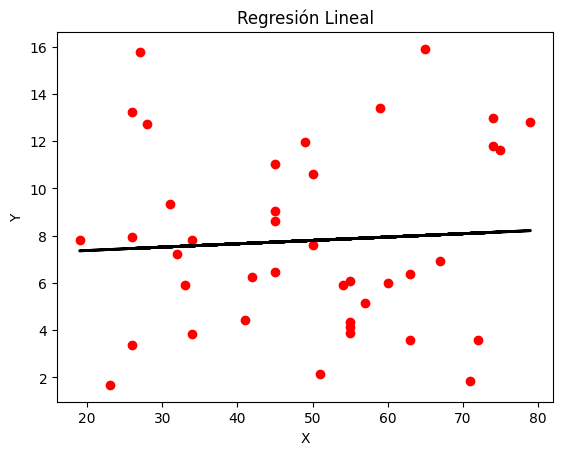

In [4]:
from sklearn import linear_model

# Creamos un objeto de regresión lineal
linear_regressor = linear_model.LinearRegression()

# Ajustamos la regresión a los datos de entrenamiento
linear_regressor.fit(X_entrenamiento, Y_entrenamiento)

# Y a partir de datos de regresión encontrados
Y_predicha_de_entrenamiento = linear_regressor.predict(X_entrenamiento)

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_entrenamiento, Y_entrenamiento, color='red')
plt.plot(X_entrenamiento, Y_predicha_de_entrenamiento, color='black', linewidth=2)
plt.title('Regresión Lineal')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


Te proponemos entonces que realices ahora la siguiente actividad con los conceptos leídos anteriormente.

Para esta actividad se ha creado un archivo usuarios_win_mac_lin.csv con datos de entrada a modo de ejemplo para clasificar si el usuario que visita un sitio web usa como sistema operativo Windows, Macintosh o Linux.

Nuestra información de entrada son 4 características que se tomó de una web que utiliza Google Analytics y son:

●      Duración de la visita en Segundos

●      Cantidad de Páginas Vistas durante la Sesión

●      Cantidad de Acciones del usuario (click, scroll, uso de checkbox, sliders,etc)

●      Suma del Valor de las acciones (cada acción lleva asociada una valoración de importancia)

Como la salida es discreta, asignaremos los siguientes valores a las etiquetas:

0 – Windows

1 – Macintosh

2 -Linux

Tu tarea es crear una Jupyter Notebook Regresion_logistica.ipynb que permita predecir qué sistema operativo utiliza un usuario según los datos de entrada.

¿Cómo pudiste llevar adelante esta actividad? te pareció muy difícil o muy fácil?  ¿por qué?  Por favor compartí tu respuesta en el foro del Campus



Columnas del dataset:
- **id**: Cantidad de registros
- **duración**: Duración de la visita en Segundos
- **paginas**: Cantidad de Páginas Vistas durante la Sesión
- **acciones**:  Cantidad de Acciones del usuario (click, scroll, uso de checkbox, sliders,etc)
- **valor**: Suma del Valor de las acciones (cada acción lleva asociada una valoración de importancia)
- **clase**: la salida es discreta, asignaremos los siguientes valores a las etiquetas:

0 – Windows

1 – Macintosh

2 -Linux

# OBJETIVO: Crear un modelo que permita predecir qué sistema operativo utiliza un usuario según los datos de entrada.

In [5]:
dat_csv = pd.read_csv('usuarios_win_mac_lin.csv', encoding = "ISO-8859-1")
dat_csv.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


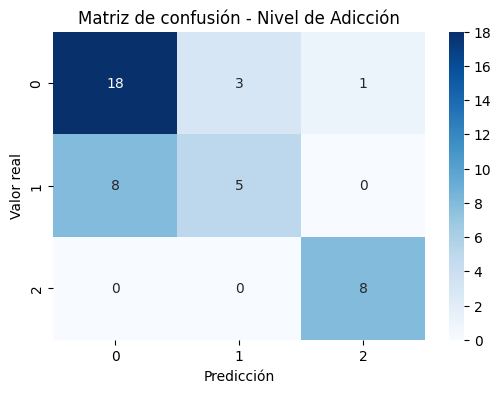

              precision    recall  f1-score   support

           0       0.69      0.82      0.75        22
           1       0.62      0.38      0.48        13
           2       0.89      1.00      0.94         8

    accuracy                           0.72        43
   macro avg       0.74      0.73      0.72        43
weighted avg       0.71      0.72      0.70        43



In [6]:
# dataset ficticio
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Convertir variables categóricas en variables dummies (0/1)
usu_encoded = pd.get_dummies(dat_csv, drop_first=True)

# Separamos las variables predictoras (X) y la variable objetivo (y)
X_adiccion = usu_encoded.drop("clase", axis=1)
y_adiccion = usu_encoded["clase"]

# 25% de prueba y 75% de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X_adiccion, y_adiccion, test_size=0.25, random_state=42)

# Creamos el modelo de regresión logística binaria
log_reg_binaria = LogisticRegression(max_iter=1000)
log_reg_binaria.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred_usu = log_reg_binaria.predict(X_test)

# Matriz de confusión para comparar valores reales vs predicciones
cm_usu = confusion_matrix(y_test, y_pred_usu)
plt.figure(figsize=(6,4))
sns.heatmap(cm_usu, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title("Matriz de confusión - Nivel de Adicción")
plt.ylabel("Valor real")
plt.xlabel("Predicción")
plt.show()
print(classification_report(y_test, y_pred_usu))
